In [1]:
from graphviz import Digraph

def visualize_tree(tree):
    if tree is None : return "Nothing in the tree!!!"

    def add_node_edges(tree,dot = None):
        #Diagraph object creation
        if dot is None:
            dot = Digraph()
            dot.attr("node",shape = "circle")
            dot.node(name=str(tree),label = str(tree.val))

        for child in [tree.left,tree.right]:
            if child is not None:
                if child == tree.right : dot.attr("node",shape="doublecircle",style = "filled" )#,color = "green")
                if child == tree.left : dot.attr("node",shape="circle",style = "filled")#,color = "blue")

                dot.node(name=str(child),label = str(child.val))
                dot.edge(str(tree),str(child))
                dot = add_node_edges(child , dot = dot)
            

        return dot

    dot = add_node_edges(tree)

    display(dot)

### Binary Tree

In [2]:
class TreeNode:              #A tree does not need  node/nodes separately!!!
    
    def __init__(self, val, left = None, right = None):
        
        self.val = val       #value could be anything
          
        self.left = left     #same as next
        self.right = right   #same as next


In [3]:
t1  = TreeNode(1)

t1.left = TreeNode(3)
t1.right = TreeNode(2)

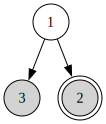

In [4]:
visualize_tree(t1)

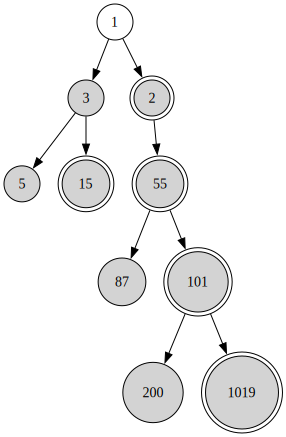

In [5]:
t1.left.left = TreeNode(5)
t1.left.right = TreeNode(15)

t1.right.right = TreeNode(55)
t1.right.right.left =  TreeNode(87)
t1.right.right.right = TreeNode(101)
t1.right.right.right.right = TreeNode(1019)
t1.right.right.right.left = TreeNode(200)

visualize_tree(t1)

# Depth First Search

#### It is done using recurson.
#### First traversal is done on Left side(left tree)  : Then on right side

In [6]:
def dfs(self):                #preorder : operation  at first 
    
    print(self.val)           #operation : that could be any function

    if self.left:             #which is same as : if self.left is not None:
        self.left.dfs()
    
    if self.right:
        self.right.dfs()

TreeNode.dfs = dfs #generally when Depth First Search is  said : It is meant

In [7]:
t1.dfs()

1
3
5
15
2
55
87
101
200
1019


In [8]:
def dfs_inorder(self): #inorder  : operation in center
    if self.left:
        self.left.dfs_inorder()

    
    print(self.val) #operation : that could be any function

    
    if self.right:
        self.right.dfs_inorder()

TreeNode.dfs_inorder = dfs_inorder

5
3
15
1
2
87
55
200
101
1019


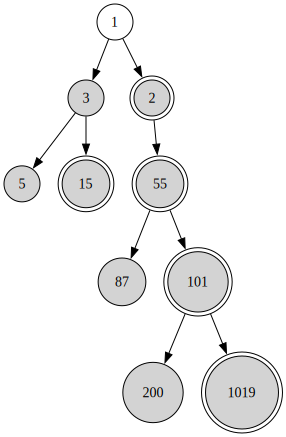

In [9]:
t1.dfs_inorder()
visualize_tree(t1)

In [10]:
def dfs_postorder(self): #postorder : operation at the end
    if self.left:
        self.left.dfs_postorder()

    if self.right:
        self.right.dfs_postorder()

    print(self.val) #operation : that could be any function

TreeNode.dfs_postorder = dfs_postorder

In [11]:
t1.dfs_postorder()

5
15
3
87
200
1019
101
55
2
1


# Breadth First Search 


##### So essencially we use list to hold elements on which operation is to be performed.
##### Then we perform operation(function) like a queue using pop(0) on that list.


In [12]:
def bfs(self):
    
    to_visit = [self] #we passed self in here!!! so the tree calling it will come to it : in our case : (1)

    while to_visit:
        current = to_visit.pop(0)

        print(current.val) #could be any operation(function)

        if current.left:
            to_visit.append(current.left)
        if current.right:
            to_visit.append(current.right)

TreeNode.bfs = bfs

In [13]:
t1.bfs()

1
3
2
5
15
55
87
101
200
1019


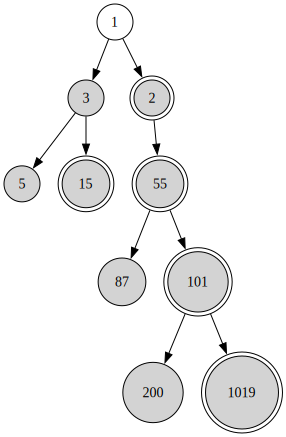

In [14]:
visualize_tree(t1)

In [15]:
def dfs_apply(self,fn): #making a structure that takes the functoin to be performed in dfs in preorder traversal.
    fn(self)            #self is passed in place of node in the function(p.process)!!!

    if self.right:
        self.right.dfs_apply(fn)
    
    if self.left:
        self.left.dfs_apply(fn)

TreeNode.dfs_apply = dfs_apply

In [16]:
class PerformSum: #doing it using class 
    def __init__(self):
        self.sum = 0
    
    def process(self,node):
        self.sum += node.val #node.val will become self.val !!!
   
    def get_sum(self):
        return self.sum
   
    def reset_sum(self):
        self.sum = 0

p = PerformSum()

In [17]:
t1.dfs_apply(p.process)
print(p.get_sum())
p.reset_sum()

1488


# Some Tree Termonologies

#### Full binary tree has either 0 nodes or 2 nodes

#### Complete binary Tree has all levels filled (possibly) except last ==>to left

### Compare it with the current node's value :  if its smaller then insert at left oterwise if its greater then insert at right

# Binary Search Tree

In [2]:
class TreeNode(): # Its a parent class
    def __init__(self,x):
        self.val = x
        self.left = None
        self.right = None


In [3]:
class BST(TreeNode): # BST(binary search tree) is the child class and it extends parent class TreeNode : AKA python syntax
    def __init__(self,val,parent = None):
        
        super().__init__(val)
        
        self.parent = parent  #to keep track we set the node to parent

    
    
    def insert(self,val):
        
        if val < self.val:  #insert into left
            if self.left is None:
                new_node = BST(val , parent = self)     # "parent = self" :to keep track we set the node to parent
                self.left = new_node
            else:
                self.left.insert(val)  #recursion!!!


        else:               #greater
            if self.right is None:
                self.right = BST(val, parent = self)   # "parent = self" :to keep track we set the node to parent
            else:
                self.right.insert(val) #recursion!!! 


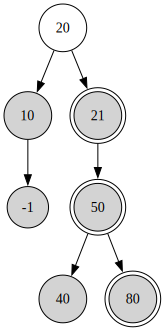

In [20]:
b = BST(20)
b.insert(10)
b.insert(21)
b.insert(50)
b.insert(-1)
b.insert(40)
b.insert(80)
visualize_tree(b)

# Searching

In [21]:
def inorder(self):
    result = []
    
    if self.left:
        result.extend(self.left.inorder())


    
    result.append(self.val)
    
    
    if self.right:
        result.extend(self.right.inorder())
    
    
    return result
BST.inorder = inorder

In [22]:
b.inorder()

[-1, 10, 20, 21, 40, 50, 80]

In [23]:
def search_by_val(value):
    l = b.inorder()
    for val in l:
        if val == value:
            return True
    
    return False
        


In [24]:
search_by_val(50)

True